# AAV5 — simulation de l'expérience avec la classe `Protocol`

Pendant AAV5 de `AAV9_potts_GT_fitting_protocol.ipynb` : on branche les **poids de Potts
récupérés** sur `sequence_classesV1.ProtocolV3` et on simule **un round complet** de
`loop_DE()`, puis on compare le résultat simulé aux **vraies mesures AAV5**.

**Correspondance protocole ↔ données AAV5** (un seul `loop_DE()` — l'expérience réelle est
plasmide → virus → organoïde) :

| étape protocole | pool | checkpoint NGS | colonne AAV5 réelle |
|---|---|---|---|
| librairie initiale | `lambda0` | `lambda0p` | `compte_plasmide` |
| `produce_capsids()` (viabilité, `F_viab`/`J_viab`) | `lambda2` | `lambda2p` | `compte_virus` |
| `selectivity()` (sélectivité, `F_sel`/`J_sel`) | `lambda3` | `lambda3p` | `compte_organoide_{i}_adn` |

- log enrichment **viabilité** simulé : `log2((lambda2p+ε)/(lambda0p+ε))` ↔ réel
  `log2_enrichissement_virus_sur_plasmide`
- log enrichment **sélectivité** simulé : `log2((lambda3p+ε)/(lambda2p+ε))` ↔ réel
  `log2_enrichissement_organoide_{2,3}_adn_sur_virus` (on simule 3 fois avec des clés
  différentes pour avoir 3 « réplicats » simulés en regard des 3 réplicats organoïde réels)

**Poids utilisés** :
- viabilité : `aav5_{F,J}_viab_potts_sorted_unreg.npy` (`AAV5_SEL_potts_regression.ipynb`,
  held-out r ≈ 0.20 — faible, cf. le cap `plasmide ≤ 500` du CSV de travail)
- sélectivité : `aav5_{F,J}_sel_pool_potts_sorted_readoutT20_unreg.npy` (fit mutualisé
  org2+org3 à `compte ≥ 20`, `AAV5_SEL_potts_readout_depth.ipynb` §6)

**⚠ Paramètres du protocole (mu, T, noise, D) NON calibrés pour AAV5** — repris du point de
fonctionnement AAV9, `T_viab = T_sel = 1/ln 2` (choix naturel : les poids prédisent un `log2`,
donc `exp(score/T)` = `2^score` est auto-cohérent). Premier passage : on regarde si les formes
de distribution et le classement des variants tiennent, pas si les échelles collent.

**Sorties** : distributions log enrichment réel (org2, org3) vs protocole (viab **et** sél),
scatter score/log-enrichment, et **recovery des meilleurs variants** (percentile `precision_at_k`).

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
LIB = _root / "lib"

from analysisV1 import (AA_LABELS, pearson, precision_at_k, topk_recovery,
                        number_of_seq_threshold, proportion_above_threshold)
from sequence_classesV1 import ProtocolV3, message as scv_msg
print("sequence_classesV1:", scv_msg, "| JAX:", jax.default_backend(), jax.devices())

CSV = Path("AAV5_organoides_sorted.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides_sorted.csv"
assert CSV.exists(), CSV

viab_col = "log2_enrichissement_virus_sur_plasmide"
sel_cols = {2: "log2_enrichissement_organoide_2_adn_sur_virus",
            3: "log2_enrichissement_organoide_3_adn_sur_virus"}
cnt_cols = {2: "compte_organoide_2_adn", 3: "compte_organoide_3_adn"}
use = ["sequence", "compte_virus", viab_col, *sel_cols.values(), *cnt_cols.values()]
df = pd.read_csv(CSV, usecols=use, dtype={c: "float32" for c in use if c != "sequence"} | {"sequence": "string"})
df["sequence"] = df["sequence"].astype("string")
print("CSV de travail:", df.shape)

L, A = 7, 20
lut = np.zeros(256, np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)

virus  = df["compte_virus"].to_numpy(np.float64)
y_viab = df[viab_col].to_numpy(np.float64)
y_sel  = {i: df[sel_cols[i]].to_numpy(np.float64) for i in (2, 3)}
c_sel  = {i: df[cnt_cols[i]].to_numpy(np.float64) for i in (2, 3)}

T_READOUT = 20      # seuil readout (cf. AAV5_SEL_potts_readout_depth.ipynb) pour "vraie mesure sélectivité"
sel_ok = {i: np.isfinite(y_sel[i]) & (c_sel[i] >= T_READOUT) & (virus >= T_READOUT) for i in (2, 3)}
print(f"variants avec vraie mesure sélectivité (T≥{T_READOUT}) : org2 {sel_ok[2].sum():,}  org3 {sel_ok[3].sum():,}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sequence_classesV1: file 2.1 | JAX: gpu [CudaDevice(id=0)]


CSV de travail: (3822400, 7)


variants avec vraie mesure sélectivité (T≥20) : org2 129,477  org3 99,206


In [2]:
# --- poids ---
F_viab = np.load(LIB / "aav5_F_viab_potts_sorted_unreg.npy")
J_viab = np.load(LIB / "aav5_J_viab_potts_sorted_unreg.npy")
F_sel  = np.load(LIB / "aav5_F_sel_pool_potts_sorted_readoutT20_unreg.npy")
J_sel  = np.load(LIB / "aav5_J_sel_pool_potts_sorted_readoutT20_unreg.npy")
print("F_viab", F_viab.shape, "J_viab", J_viab.shape, "| F_sel", F_sel.shape, "J_sel", J_sel.shape)


def score_FJ(seq, F, J):
    F, J = np.asarray(F, np.float64), np.asarray(J, np.float64)
    s = F[seq, np.arange(L)].sum(axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            s = s + J[i, j, seq[:, i], seq[:, j]]
    return s


# --- sous-échantillon pour la simulation (loop_DE sur 3.8M lignes = trop lourd) ---
D0_SIM = 400_000
priority = sel_ok[2] | sel_ok[3]
rng = np.random.default_rng(0)
n_extra = max(0, D0_SIM - int(priority.sum()))
extra = rng.choice(np.flatnonzero(~priority), size=min(n_extra, int((~priority).sum())), replace=False)
sim_rows = np.sort(np.concatenate([np.flatnonzero(priority), extra]))
print(f"D0_SIM = {len(sim_rows):,}  (dont {int(priority.sum()):,} avec vraie mesure sélectivité + "
      f"{len(extra):,} de fond aléatoire)")

sim_seq   = seq_matrix[sim_rows]
sim_yviab = y_viab[sim_rows]
sim_ysel  = {i: y_sel[i][sim_rows] for i in (2, 3)}
sim_selok = {i: sel_ok[i][sim_rows] for i in (2, 3)}
sequences = jnp.asarray(sim_seq)
d0 = len(sim_rows)

F_viab (20, 7) J_viab (7, 7, 20, 20) | F_sel (20, 7) J_sel (7, 7, 20, 20)
D0_SIM = 400,000  (dont 163,325 avec vraie mesure sélectivité + 236,675 de fond aléatoire)


## 1. Score GT déterministe vs cible réelle (avant toute simulation)

`compute_score(F, J)` = `F + J` sans aucun bruit de protocole. C'est le **plafond** de ce que la
simulation peut espérer : si le score GT ne classe pas déjà bien la vraie expérience, le
protocole (qui ne fait qu'ajouter du bruit d'échantillonnage par-dessus) ne fera pas mieux.

r(score GT viab, réel viab)          = +0.196   (n=400,000)
r(score GT sél, réel org2, T≥20) = +0.560   (n=129,477)
r(score GT sél, réel org3, T≥20) = +0.481   (n=99,206)


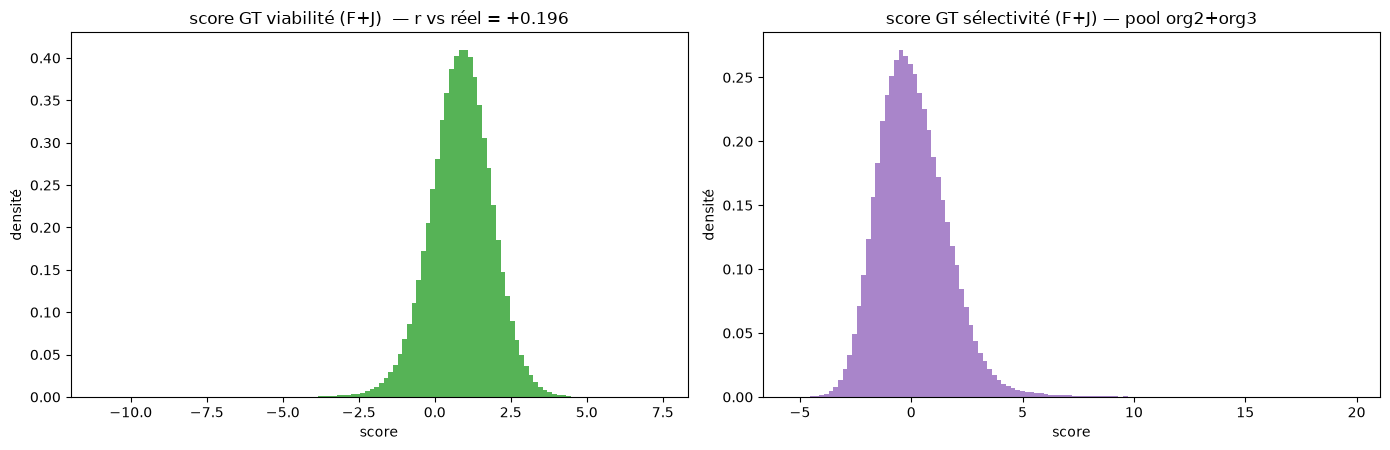

In [3]:
viab_score_GT = score_FJ(sim_seq, F_viab, J_viab)
sel_score_GT  = score_FJ(sim_seq, F_sel,  J_sel)

r_viab_gt = pearson(sim_yviab, viab_score_GT)
r_sel_gt  = {i: pearson(sim_ysel[i][sim_selok[i]], sel_score_GT[sim_selok[i]]) for i in (2, 3)}
print(f"r(score GT viab, réel viab)          = {r_viab_gt:+.3f}   (n={d0:,})")
for i in (2, 3):
    print(f"r(score GT sél, réel org{i}, T≥{T_READOUT}) = {r_sel_gt[i]:+.3f}   (n={sim_selok[i].sum():,})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].hist(viab_score_GT, bins=120, density=True, color="tab:green", alpha=0.8)
axes[0].set(title=f"score GT viabilité (F+J)  — r vs réel = {r_viab_gt:+.3f}",
            xlabel="score", ylabel="densité")
axes[1].hist(sel_score_GT, bins=120, density=True, color="tab:purple", alpha=0.8)
axes[1].set(title="score GT sélectivité (F+J) — pool org2+org3",
            xlabel="score", ylabel="densité")
plt.tight_layout(); plt.show()

## 2. Configuration du protocole + un round simulé

`ProtocolV3`, `multinomialNGS=True`. Paramètres **non calibrés** (repris d'AAV9) — à ajuster
dans cette cellule. On lance `loop_DE()` 3 fois (clés différentes) pour 3 réplicats simulés de
sélectivité.

In [4]:
RHO        = 1e-3
MU         = 50
T_VIAB     = 1.0 / np.log(2)     # 2^score : auto-cohérent, les poids prédisent un log2
T_SEL      = 1.0 / np.log(2)
NOISE_VIAB = 0.5
NOISE_SEL  = 0.5
D          = 1e8                 # profondeur NGS ~ totaux réels AAV5 (plasmide ~1.2e8, virus ~1.8e8)
DILUTION   = 1e5
EPS        = 0.5                 # convention projet (2026-09-11) : toujours eps=0.5 pour un log2 enrichment
N1 = MU * d0 / RHO
N0 = 150 * N1
print(f"mu={MU}  T_viab=T_sel={T_VIAB:.3f}  noise={NOISE_VIAB}/{NOISE_SEL}  D={D:.0e}  "
      f"N1={N1:.2e}  N0={N0:.2e}  D/d0={D/d0:.1f} reads/variant")


def simulate_round(seed):
    p = ProtocolV3(key=jax.random.PRNGKey(seed), N0=N0, N1=N1, dilution_factor=DILUTION,
                   sequences=sequences, D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
                   noise_viab=NOISE_VIAB, noise_sel=NOISE_SEL, T_viab=T_VIAB, T_sel=T_SEL,
                   multinomialNGS=True, rho=RHO)
    bio, ngs = p.loop_DE()
    l0p, l2p, l3p = (np.asarray(a, np.float64) for a in ngs)
    sim_viab = np.log2((l2p + EPS) / (l0p + EPS))
    sim_sel  = np.log2((l3p + EPS) / (l2p + EPS))
    return dict(p=p, l0p=l0p, l2p=l2p, l3p=l3p, sim_viab=sim_viab, sim_sel=sim_sel)


sims = [simulate_round(s) for s in (0, 1, 2)]
sim_viab = sims[0]["sim_viab"]
print("un round simulé x3  ok")
for k, s in enumerate(sims):
    finite = np.isfinite(s["sim_sel"])
    print(f"  rep{k}: sim_viab fini {np.isfinite(s['sim_viab']).mean():.2%}  "
          f"sim_sel fini {finite.mean():.2%}  (l3p>0 : {(s['l3p']>0).mean():.2%})")

mu=50  T_viab=T_sel=1.443  noise=0.5/0.5  D=1e+08  N1=2.00e+10  N0=3.00e+12  D/d0=250.0 reads/variant


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   2%|▎         | 1/40 [00:01<00:40,  1.03s/it]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:  95%|█████████▌| 38/40 [00:00<00:00, 377.71it/s]

...

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:  85%|████████▌ | 34/40 [00:00<00:00, 335.90it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:  80%|████████  | 32/40 [00:00<00:00, 314.92it/s]

un round simulé x3  ok
  rep0: sim_viab fini 100.00%  sim_sel fini 100.00%  (l3p>0 : 87.99%)
  rep1: sim_viab fini 100.00%  sim_sel fini 100.00%  (l3p>0 : 88.00%)
  rep2: sim_viab fini 100.00%  sim_sel fini 100.00%  (l3p>0 : 88.01%)


## 3. Viabilité — distribution réelle vs protocole

`log2_enrichissement_virus_sur_plasmide` réel vs `log2((lambda2p+ε)/(lambda0p+ε))` simulé.
Les deux **recalés sur leur médiane** (le réel est un ratio normalisé, le simulé un ratio de
reads bruts — l'offset log2 constant ne porte pas d'info et n'affecte ni `r` ni les recoveries).

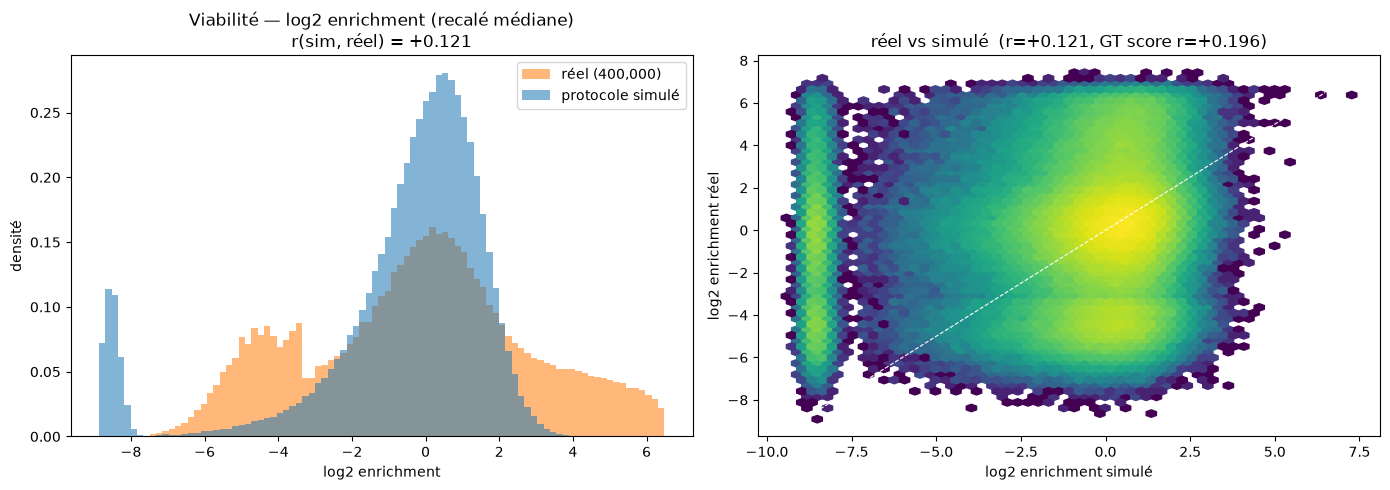

In [5]:
def center(x):
    x = np.asarray(x, np.float64)
    return x - np.median(x[np.isfinite(x)])

rv, sv = center(sim_yviab), center(sim_viab)
mfin = np.isfinite(rv) & np.isfinite(sv)
r_viab_sim = pearson(rv[mfin], sv[mfin])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lo, hi = np.percentile(np.concatenate([rv[mfin], sv[mfin]]), [0.2, 99.8])
bins = np.linspace(lo, hi, 90)
axes[0].hist(rv[mfin], bins=bins, density=True, alpha=0.55, color="tab:orange", label=f"réel ({mfin.sum():,})")
axes[0].hist(sv[mfin], bins=bins, density=True, alpha=0.55, color="tab:blue",   label="protocole simulé")
axes[0].set(title=f"Viabilité — log2 enrichment (recalé médiane)\nr(sim, réel) = {r_viab_sim:+.3f}",
            xlabel="log2 enrichment", ylabel="densité"); axes[0].legend()

axes[1].hexbin(sv[mfin], rv[mfin], gridsize=55, bins="log", cmap="viridis", mincnt=1)
d = [max(sv[mfin].min(), lo), min(sv[mfin].max(), hi)]
axes[1].plot(d, d, "w--", lw=0.8)
axes[1].set(title=f"réel vs simulé  (r={r_viab_sim:+.3f}, GT score r={r_viab_gt:+.3f})",
            xlabel="log2 enrichment simulé", ylabel="log2 enrichment réel")
plt.tight_layout(); plt.show()

## 4. Sélectivité — distributions réelles (org2, org3) vs protocole

`log2_enrichissement_organoide_{2,3}_adn_sur_virus` réel (variants à `compte ≥ 20`, la « vraie
mesure ») vs `log2((lambda3p+ε)/(lambda2p+ε))` simulé, 3 réplicats simulés. Tout recalé médiane.

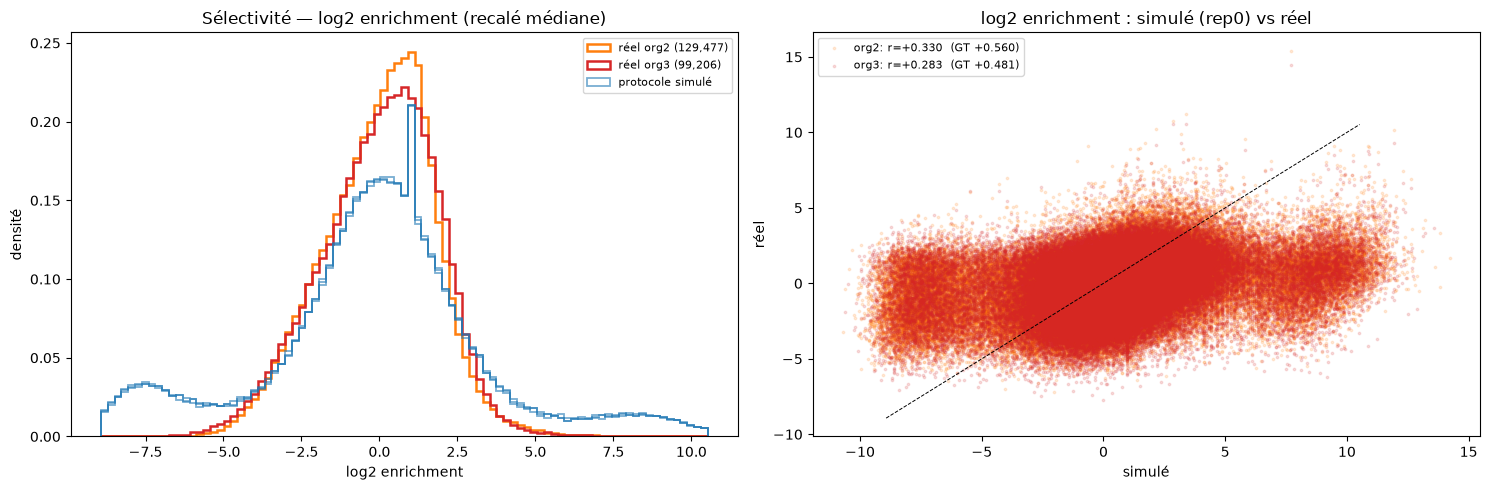

accord réplicat-réplicat :
  réel   org2 vs org3            : +0.850
  simulé rep0 vs rep1            : +0.389
  simulé rep0 vs rep2            : +0.387


In [6]:
sims_sel_c = [center(s["sim_sel"]) for s in sims]
real_sel_c = {i: center(sim_ysel[i]) for i in (2, 3)}

# --- histogrammes superposés ---
allv = np.concatenate([real_sel_c[2][sim_selok[2]], real_sel_c[3][sim_selok[3]]]
                      + [ss[np.isfinite(ss)] for ss in sims_sel_c])
lo, hi = np.percentile(allv, [0.5, 99.5])
bins = np.linspace(lo, hi, 90)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(real_sel_c[2][sim_selok[2]], bins=bins, density=True, histtype="step", lw=1.8,
             color="tab:orange", label=f"réel org2 ({sim_selok[2].sum():,})")
axes[0].hist(real_sel_c[3][sim_selok[3]], bins=bins, density=True, histtype="step", lw=1.8,
             color="tab:red", label=f"réel org3 ({sim_selok[3].sum():,})")
for k, ss in enumerate(sims_sel_c):
    axes[0].hist(ss[np.isfinite(ss)], bins=bins, density=True, histtype="step", lw=1.3,
                 color="tab:blue", alpha=0.6, label="protocole simulé" if k == 0 else None)
axes[0].set(title="Sélectivité — log2 enrichment (recalé médiane)",
            xlabel="log2 enrichment", ylabel="densité"); axes[0].legend(fontsize=8)

# --- scatter simulé (rep0) vs réel org2 / org3 ---
s0 = sims_sel_c[0]
for i, col in zip((2, 3), ("tab:orange", "tab:red")):
    m = sim_selok[i] & np.isfinite(s0)
    r = pearson(real_sel_c[i][m], s0[m])
    axes[1].scatter(s0[m], real_sel_c[i][m], s=3, alpha=0.15, color=col,
                    label=f"org{i}: r={r:+.3f}  (GT {r_sel_gt[i]:+.3f})")
axes[1].plot([lo, hi], [lo, hi], "k--", lw=0.7)
axes[1].set(title="log2 enrichment : simulé (rep0) vs réel", xlabel="simulé", ylabel="réel")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# --- accord réplicat à réplicat : simulé vs réel ---
def r_between(a, b, mask=None):
    a, b = np.asarray(a), np.asarray(b)
    m = np.isfinite(a) & np.isfinite(b)
    if mask is not None:
        m &= mask
    return pearson(a[m], b[m])

print("accord réplicat-réplicat :")
print(f"  réel   org2 vs org3            : {r_between(real_sel_c[2], real_sel_c[3], sim_selok[2] & sim_selok[3]):+.3f}")
print(f"  simulé rep0 vs rep1            : {r_between(sims_sel_c[0], sims_sel_c[1]):+.3f}")
print(f"  simulé rep0 vs rep2            : {r_between(sims_sel_c[0], sims_sel_c[2]):+.3f}")

## 5. Recovery des meilleurs variants

Pour chaque cible (viab, sél org2, sél org3) : quelle fraction du **vrai top-k%** (classé par la
mesure réelle) est retrouvée dans le top-k% classé par (a) le **score GT** déterministe, (b) le
**log enrichment simulé** par le protocole. Ligne pointillée = tirage au hasard (= k%).

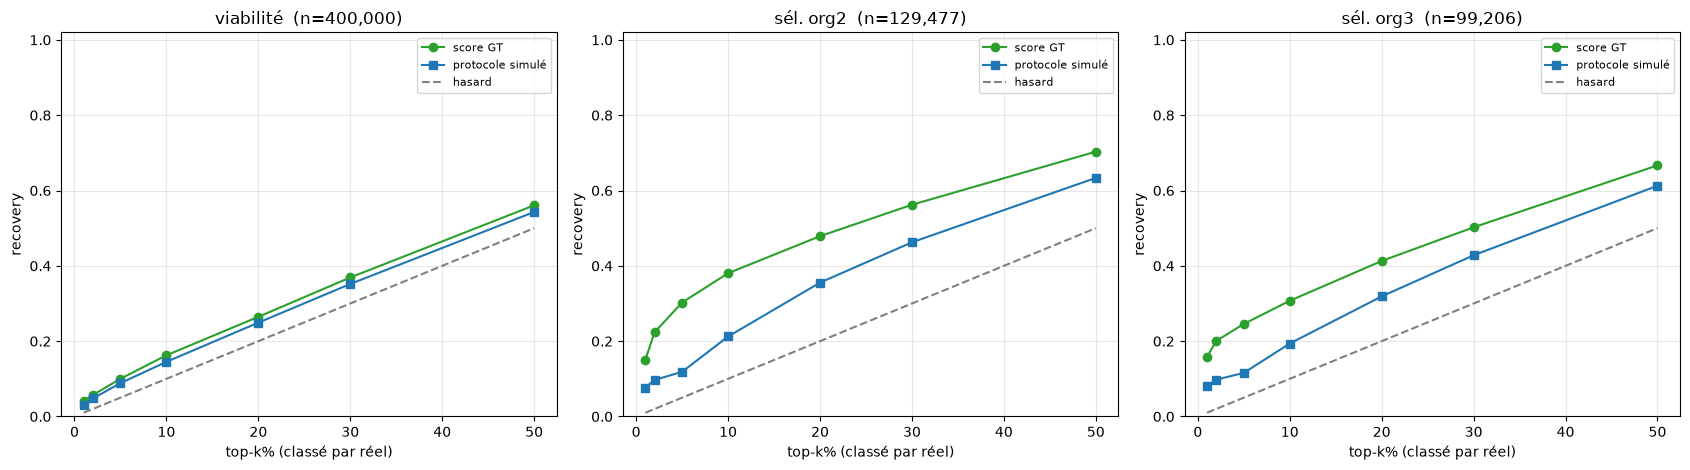

recovery_GT                     recovery_sim                    
cible    sél. org2 sél. org3 viabilité    sél. org2 sél. org3 viabilité
top_k%                                                                 
1            0.151     0.158     0.042        0.077     0.082     0.031
2            0.224     0.201     0.057        0.097     0.098     0.048
5            0.303     0.246     0.100        0.119     0.116     0.089
10           0.380     0.307     0.163        0.212     0.194     0.145
20           0.479     0.413     0.265        0.355     0.319     0.249
30           0.562     0.502     0.369        0.463     0.428     0.352
50           0.703     0.667     0.561        0.633     0.613     0.543

In [7]:
PCTS = [1, 2, 5, 10, 20, 30, 50]

def recovery_curve(y_real, ranker, mask):
    yr, rk = y_real[mask], ranker[mask]
    ok = np.isfinite(yr) & np.isfinite(rk)
    yr, rk = yr[ok], rk[ok]
    return [precision_at_k(yr, rk, k_frac=p / 100) for p in PCTS], len(yr)

targets = [
    ("viabilité",   sim_yviab,      viab_score_GT, sim_viab,           np.ones(d0, bool)),
    ("sél. org2",   sim_ysel[2],    sel_score_GT,  sims[0]["sim_sel"], sim_selok[2]),
    ("sél. org3",   sim_ysel[3],    sel_score_GT,  sims[0]["sim_sel"], sim_selok[3]),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
rows = []
for ax, (name, y_real, gt, simlog, mask) in zip(axes, targets):
    rec_gt,  n = recovery_curve(y_real, gt, mask)
    rec_sim, _ = recovery_curve(y_real, simlog, mask)
    ax.plot(PCTS, rec_gt,  "o-", color="tab:green", label="score GT")
    ax.plot(PCTS, rec_sim, "s-", color="tab:blue",  label="protocole simulé")
    ax.plot(PCTS, [p / 100 for p in PCTS], "--", color="grey", label="hasard")
    ax.set(title=f"{name}  (n={n:,})", xlabel="top-k% (classé par réel)",
           ylabel="recovery", ylim=(0, 1.02)); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    for p, g, s in zip(PCTS, rec_gt, rec_sim):
        rows.append({"cible": name, "top_k%": p, "recovery_GT": round(g, 3), "recovery_sim": round(s, 3)})
plt.tight_layout(); plt.show()
pd.DataFrame(rows).pivot(index="top_k%", columns="cible", values=["recovery_GT", "recovery_sim"])

## 6. Population à travers le pipeline simulé

Combien de variants détectés (`count ≥ seuil`) à chaque checkpoint NGS, à la profondeur `D`.

In [8]:
p0 = sims[0]["p"]
lambdas_np = {
    "lambda0 (librairie)":        np.asarray(p0.lambda0),
    "lambda0p (NGS plasmide)":    sims[0]["l0p"],
    "lambda2 (capsides)":         np.asarray(p0.lambda2),
    "lambda2p (NGS virus)":       sims[0]["l2p"],
    "lambda3 (post-sélectivité)": np.asarray(p0.lambda3),
    "lambda3p (NGS organoïde)":   sims[0]["l3p"],
}
summary = pd.DataFrame({
    "total": [a.sum() for a in lambdas_np.values()],
    "n_variants (>=1)": [int((a >= 1).sum()) for a in lambdas_np.values()],
    "fraction_d0": [float((a >= 1).mean()) for a in lambdas_np.values()],
}, index=list(lambdas_np))
display(summary)
display(number_of_seq_threshold(lambdas_np, thresholds=[1, 10, 100, 1000]))

,total,n_variants (>=1),fraction_d0
lambda0 (librairie),2.999970e+12,400000,1.000000
lambda0p (NGS plasmide),9.996891e+07,400000,1.000000
lambda2 (capsides),1.955266e+11,400000,1.000000
lambda2p (NGS virus),9.996830e+07,371717,0.929292
lambda3 (post-sélectivité),4.399624e+11,400000,1.000000
lambda3p (NGS organoïde),9.996731e+07,351977,0.879942


,1.0,10.0,100.0,1000.0
lambda,,,,
lambda0 (librairie),400000,400000,400000,400000
lambda0p (NGS plasmide),400000,400000,399998,0
lambda2 (capsides),400000,400000,400000,399992
lambda2p (NGS virus),371717,364674,277449,6778
lambda3 (post-sélectivité),400000,400000,400000,400000
lambda3p (NGS organoïde),351977,332370,181919,13047


## 7. Notes

- Les poids de **viabilité** sont faibles (held-out r ≈ 0.20) — cf. le cap `plasmide ≤ 500`
  du CSV de travail qui retire la large dynamique. Le `r(sim, réel)` de viabilité est
  plafonné par là, pas par le protocole.
- Poids de **sélectivité** = fit mutualisé org2+org3 à `compte ≥ 20`. Le plafond réel est
  `r(org2, org3) ≈ 0.88` sur ce sous-ensemble.
- **Paramètres protocole non calibrés** (mu / T / noise / D repris d'AAV9). `T = 1/ln 2` est le
  seul choix « motivé » (auto-cohérence `2^score`). Une recherche façon partie 2 d'
  `AAV9_fitting_protocol.ipynb` (mu, T_viab, T_sel, noise, D contre `r(réel, score GT)`) reste
  à faire pour AAV5.
- `D0_SIM` = 400 000 variants (sous-échantillon : `loop_DE()` sur les 3.82M est trop lourd) —
  priorité aux variants avec vraie mesure sélectivité + fond aléatoire.